In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy  as np
import seaborn  as sns


In [4]:
df = pd.read_csv("weather_data.csv")
df.head()

,Date,City,Temperature_C,Condition
0,2026-06-01,Delhi,30.7,Sunny
1,2026-06-02,Delhi,35.0,Sunny
2,2026-06-03,Delhi,34.8,Sunny
3,2026-06-04,Delhi,36.0,Cloudy
4,2026-06-05,Delhi,32.6,Partly Cloudy


In [5]:
avg_temp = df.groupby("City")["Temperature_C"].mean().round(2)
print(avg_temp)
print("\n")
hottest_city = avg_temp.idxmax()
hottest_temp = df["Temperature_C"].max()

coldest_city = avg_temp.idxmin()
clodest_temp  = df["Temperature_C"].min()
print(f"Hottest City:{hottest_city}")
print(f"Hottest Temperature:{hottest_temp}")
print("\n")
print(f"Coldest City:{coldest_city}")
print(f"Coldest Temperature:{clodest_temp}")
rainy =df[df["Condition"] == "Rainy"]
rainycount = rainy.count().sum()
print("\n")
print(f"Number of rainy days :{rainycount}")
sunny =df[df["Condition"] == "Sunny"]
sunnycount = sunny.count().sum()
print("\n")
print(f"Number of sunny days :{sunnycount}")


City
Ambala     30.12
Delhi      33.20
Gurgaon    31.55
Hisar      35.70
Karnal     31.30
Panipat    32.42
Rohtak     34.87
Sirsa      36.07
Name: Temperature_C, dtype: float64


Hottest City:Sirsa
Hottest Temperature:42.4


Coldest City:Ambala
Coldest Temperature:23.1


Number of rainy days :172


Number of sunny days :412


Condition
Sunny            103
Partly Cloudy     59
Rainy             43
Cloudy            35
Name: count, dtype: int64


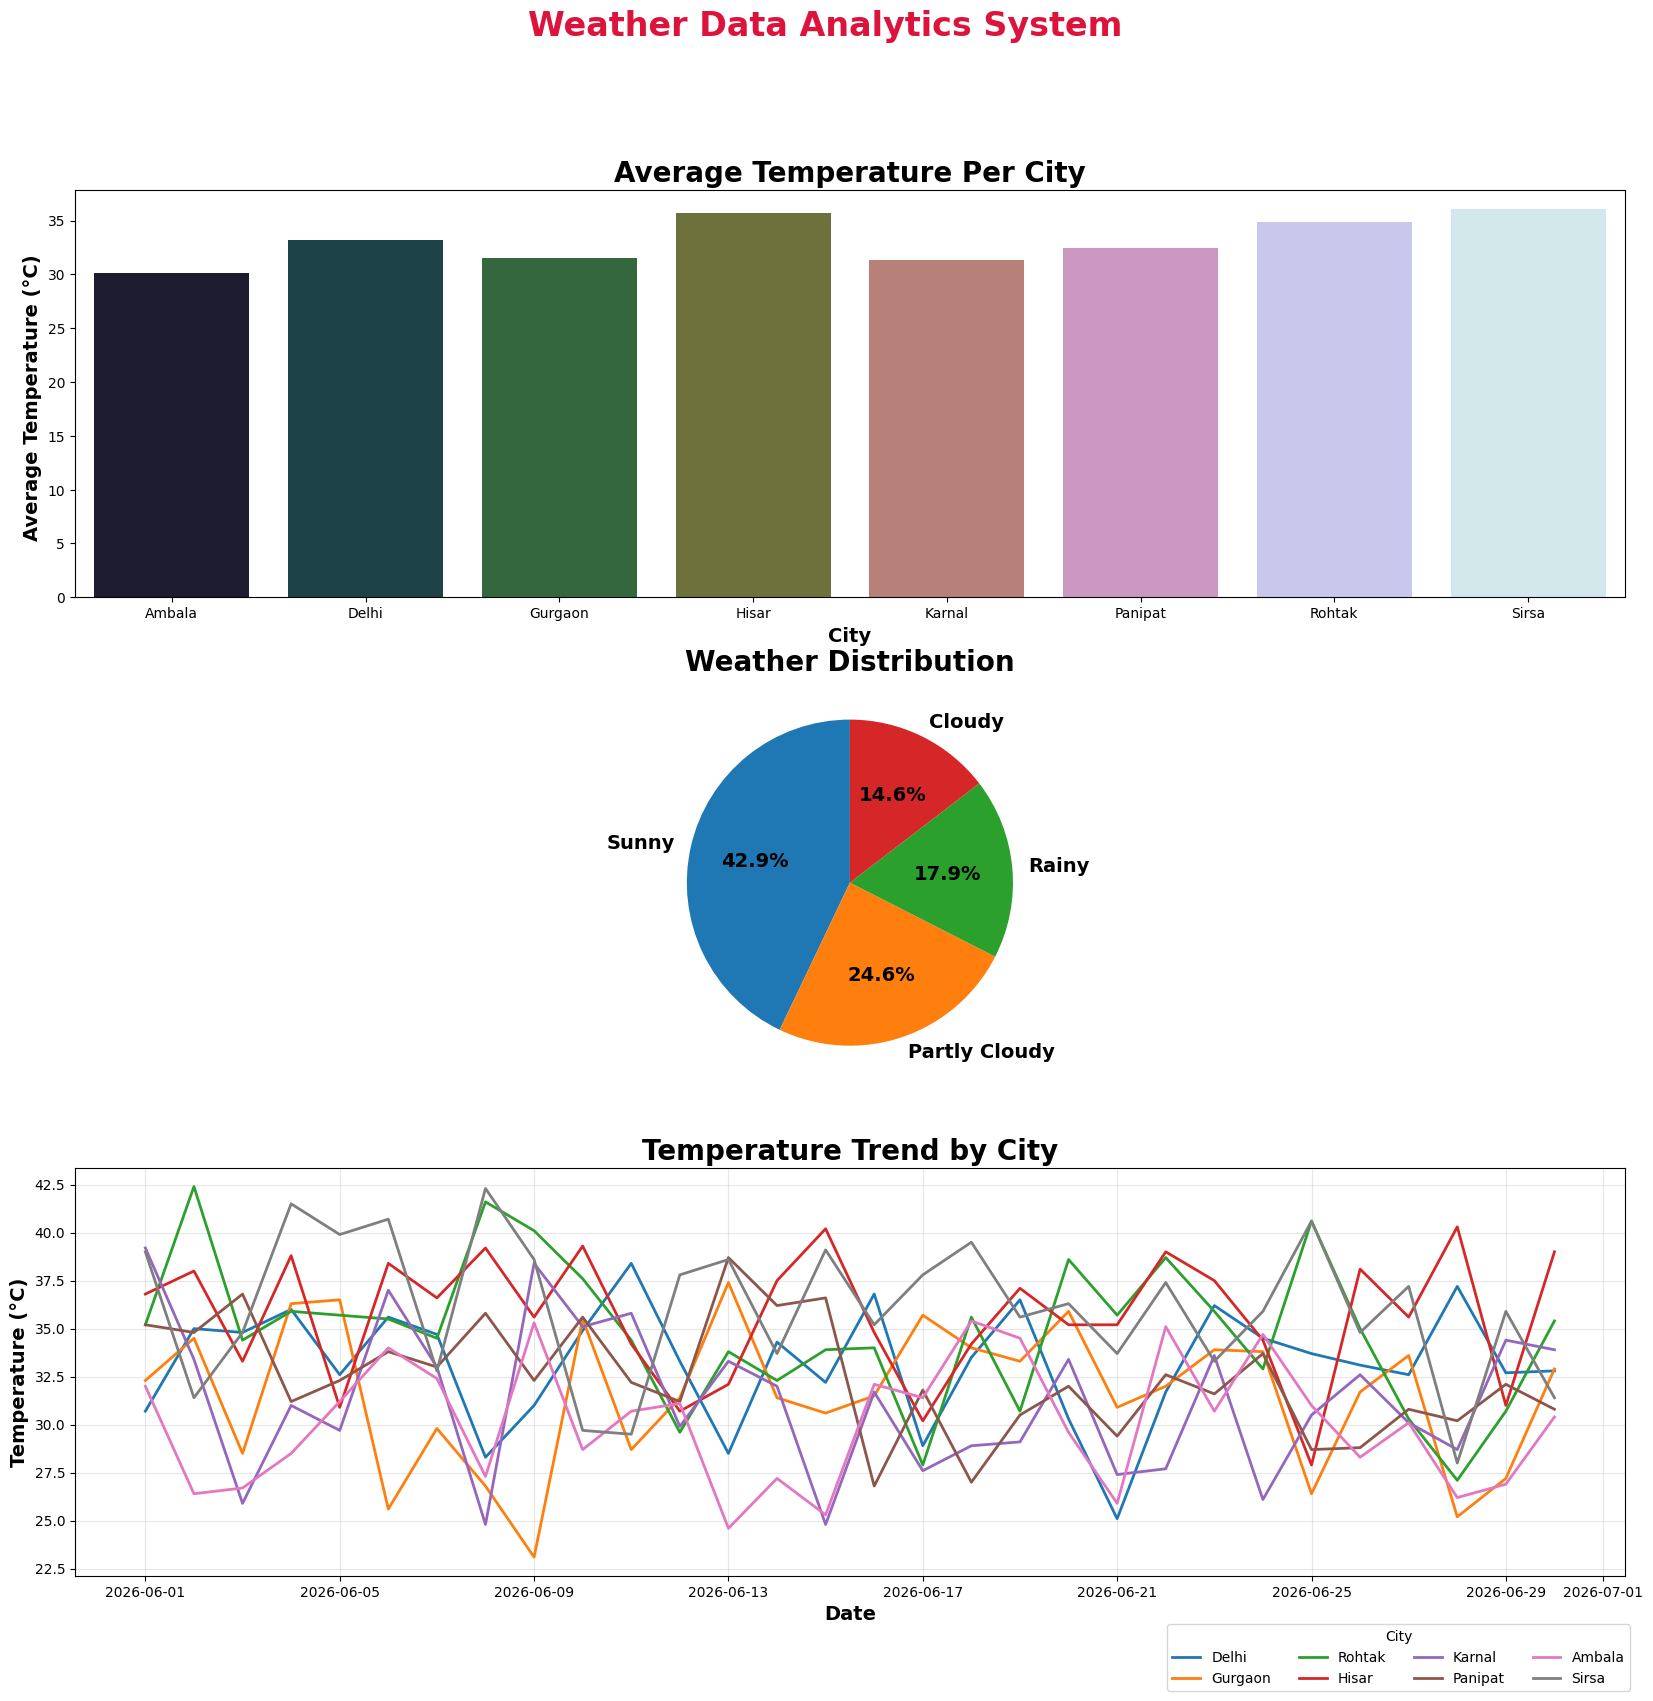

In [48]:
# 
fig,axes =plt.subplots(3,1,figsize=(20,18))
fig.suptitle("Weather Data Analytics System", fontweight='bold', fontsize = 24, color = "crimson")
avg_temp = df.groupby("City")["Temperature_C"].mean().round(2).reset_index()
sns.barplot(data=avg_temp, x='City', y='Temperature_C', palette='cubehelix', ax=axes[0] , hue = 'City')

axes[0].set_title('Average Temperature Per City', fontsize=20, fontweight='bold')
axes[0].set_xlabel('City',fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Temperature (°C) ',fontsize=14, fontweight='bold')

# Weather Distribution (Pie Chart)
weather_distribution = df["Condition"].value_counts() #count the number of days having specific conditon(like rainy,sunny)
print(weather_distribution)

axes[1].pie(weather_distribution.values,labels=weather_distribution.index,autopct="%1.1f%%",startangle=90,
                textprops={
                "fontsize": 14,
                "fontweight": "bold"})

axes[1].set_title("Weather Distribution",fontsize=20,fontweight="bold")
# Temperature Trend
#convert Date column which arepreviously string into actual datetime data
df["Date"]=pd.to_datetime(df["Date"]) 
#Create figure

for city in df["City"].unique():
    city_data = df[df["City"] == city]
    # print(city_data)
    axes[2].plot(city_data["Date"],city_data["Temperature_C"],linewidth=2,label=city)

axes[2].set_title("Temperature Trend by City",fontsize=20,fontweight="bold")

axes[2].set_xlabel("Date",fontsize=14,fontweight="bold")

axes[2].set_ylabel("Temperature (°C)",fontsize=14,fontweight="bold")

axes[2].legend(
    title="City",
    loc="lower left",
    bbox_to_anchor=(0.7, -0.3),
    ncol=4
)
axes[2].grid(alpha=0.3)





plt.show()